# 💨 Wind System Demo - OpenEnergy Platform

## Advanced Wind Turbine Generation Modeling

This notebook demonstrates the **WindSystem** class from OpenEnergy - a sophisticated wind turbine modeling system that includes:

- **🌪️ Realistic Power Curves** - Cut-in, rated, and cut-out wind speeds
- **📐 Hub Height Effects** - Wind shear and height adjustments
- **⚡ Efficiency Modeling** - Performance degradation over time
- **🌡️ Environmental Factors** - Temperature and air density impacts
- **🔧 Technical Constraints** - Operational limits and maintenance scheduling

### 🎯 Use Cases
- **Wind Farm Planning** - Optimize turbine placement and sizing
- **Energy Forecasting** - Predict generation based on weather data
- **Performance Analysis** - Monitor degradation and maintenance needs
- **Portfolio Optimization** - Integrate with other renewable assets

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.append('/Users/akhilesh.koul/Documents/GitHub/OpenEnergy')

# Import OpenEnergy WindSystem
from scripts.assets.wind_system import WindSystem

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ WindSystem imported successfully!")
print("💨 Ready to model wind generation! 🌪️")

/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ WindSystem imported successfully!
💨 Ready to model wind generation! 🌪️


## 🏗️ Wind System Configuration

Let's create different wind turbine configurations to demonstrate various use cases:

In [2]:
# Create different wind system configurations

# 🌪️ Onshore Wind Farm - Standard Configuration
onshore_wind = WindSystem(
    capacity_mw=20.0,              # 20 MW wind farm
    initial_efficiency=0.95,        # 95% initial efficiency  
    degradation_rate_per_year=0.005, # 0.5% annual degradation
    cut_in_speed=3.0,              # 3 m/s cut-in speed
    rated_speed=12.0,              # 12 m/s rated speed
    cut_out_speed=25.0,            # 25 m/s cut-out speed
    hub_height=80.0                # 80m hub height
)

# 🌊 Offshore Wind Farm - High Performance
offshore_wind = WindSystem(
    capacity_mw=50.0,              # 50 MW offshore wind farm
    initial_efficiency=0.98,        # 98% initial efficiency
    degradation_rate_per_year=0.003, # 0.3% annual degradation (better maintenance)
    cut_in_speed=3.5,              # 3.5 m/s cut-in speed
    rated_speed=14.0,              # 14 m/s rated speed
    cut_out_speed=28.0,            # 28 m/s cut-out speed
    hub_height=120.0               # 120m hub height (taller for offshore)
)

# 🏔️ Mountain Wind - Smaller Turbines
mountain_wind = WindSystem(
    capacity_mw=5.0,               # 5 MW small wind farm
    initial_efficiency=0.92,        # 92% initial efficiency
    degradation_rate_per_year=0.008, # 0.8% annual degradation (harsh conditions)
    cut_in_speed=2.5,              # 2.5 m/s cut-in speed (low wind site)
    rated_speed=10.0,              # 10 m/s rated speed
    cut_out_speed=22.0,            # 22 m/s cut-out speed
    hub_height=60.0                # 60m hub height
)

print("💨 Wind System Configurations:")
print(f"🌪️ Onshore: {onshore_wind.capacity_mw} MW, Hub: {onshore_wind.hub_height}m")
print(f"🌊 Offshore: {offshore_wind.capacity_mw} MW, Hub: {offshore_wind.hub_height}m") 
print(f"🏔️ Mountain: {mountain_wind.capacity_mw} MW, Hub: {mountain_wind.hub_height}m")

# Display key parameters
print(f"\n📊 Wind Speed Parameters:")
print(f"Onshore:  Cut-in: {onshore_wind.cut_in_speed} m/s, Rated: {onshore_wind.rated_speed} m/s, Cut-out: {onshore_wind.cut_out_speed} m/s")
print(f"Offshore: Cut-in: {offshore_wind.cut_in_speed} m/s, Rated: {offshore_wind.rated_speed} m/s, Cut-out: {offshore_wind.cut_out_speed} m/s")
print(f"Mountain: Cut-in: {mountain_wind.cut_in_speed} m/s, Rated: {mountain_wind.rated_speed} m/s, Cut-out: {mountain_wind.cut_out_speed} m/s")

💨 Wind System Configurations:
🌪️ Onshore: 20.0 MW, Hub: 80.0m
🌊 Offshore: 50.0 MW, Hub: 120.0m
🏔️ Mountain: 5.0 MW, Hub: 60.0m

📊 Wind Speed Parameters:
Onshore:  Cut-in: 3.0 m/s, Rated: 12.0 m/s, Cut-out: 25.0 m/s
Offshore: Cut-in: 3.5 m/s, Rated: 14.0 m/s, Cut-out: 28.0 m/s
Mountain: Cut-in: 2.5 m/s, Rated: 10.0 m/s, Cut-out: 22.0 m/s


## 📈 Power Curve Analysis

Let's analyze the power curves of our different wind systems to understand their performance characteristics:

/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/4051634392.py:68: UserWarning: Glyph 127786 (\N{CLOUD WITH TORNADO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/4051634392.py:68: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/4051634392.py:68: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/4051634392.py:68: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/4051634392.py:68: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/

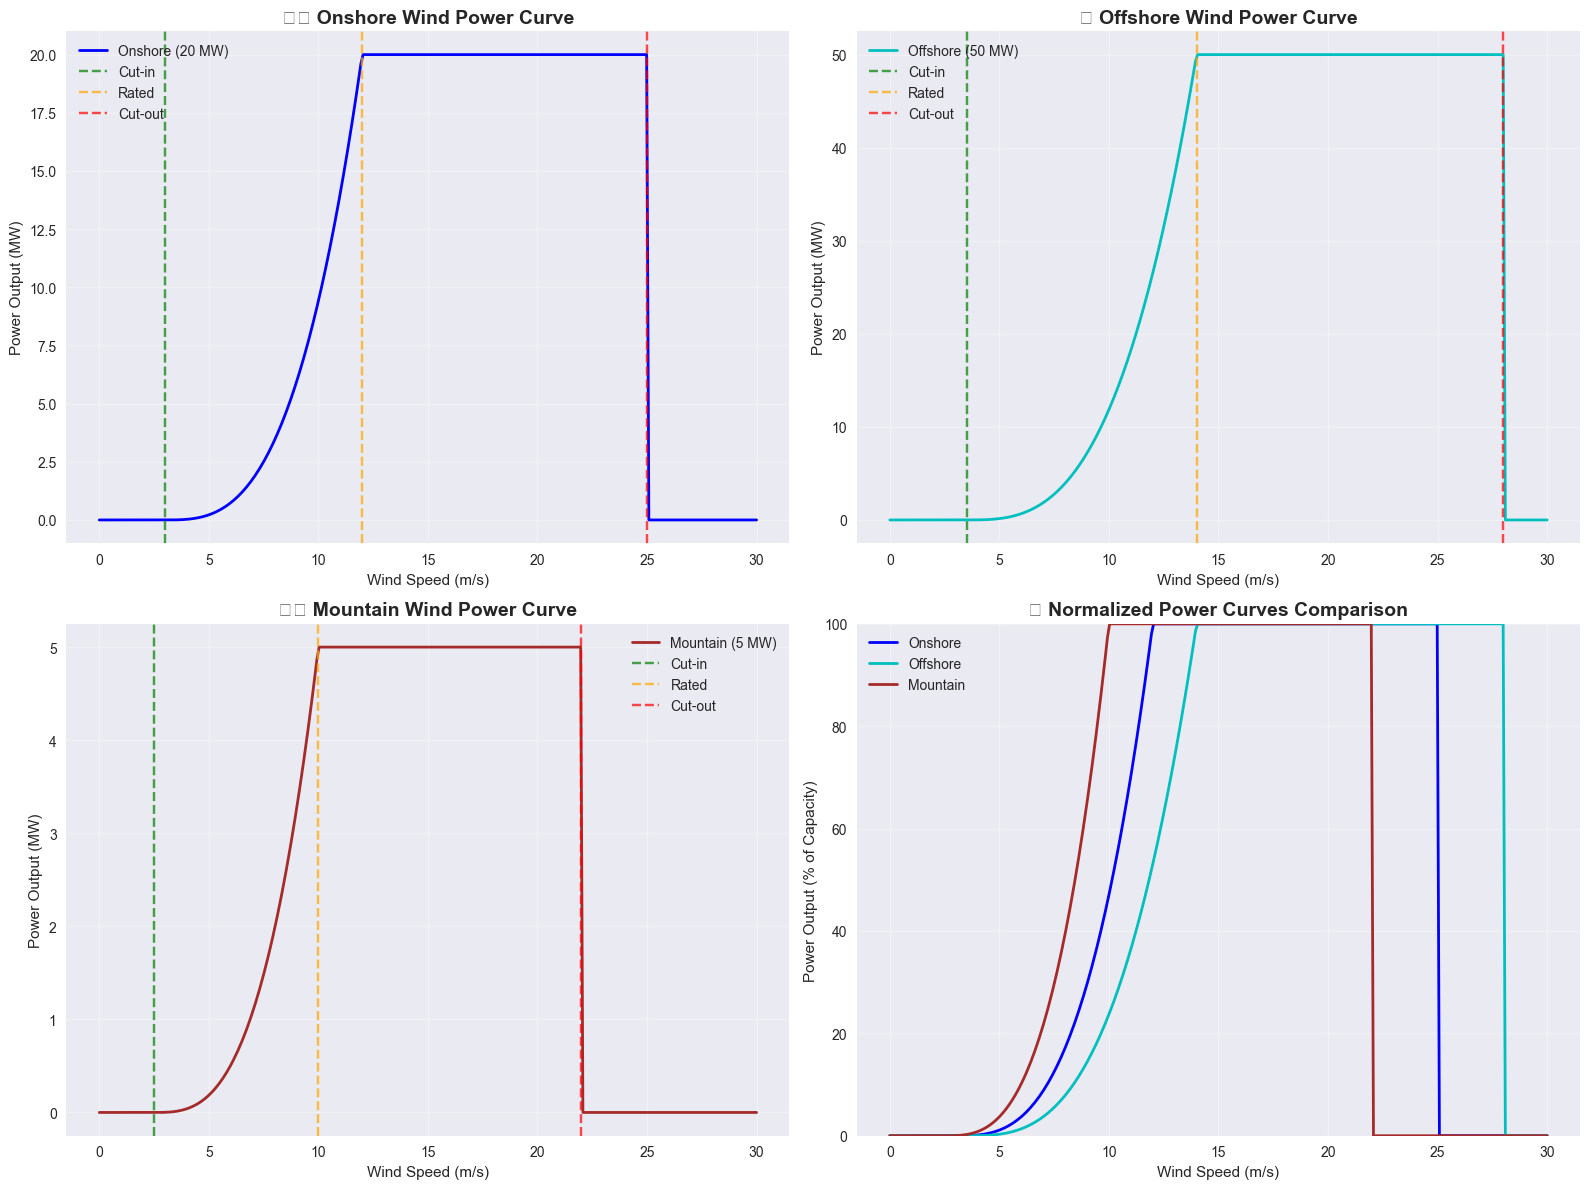

🎯 Power Curve Key Points:

Onshore Wind System:
  🟢 Cut-in Speed: 3.0 m/s
  🟠 Rated Speed: 12.0 m/s
  🔴 Cut-out Speed: 25.0 m/s
  ⚡ Rated Power: 20.0 MW
  📏 Hub Height: 80.0 m

Offshore Wind System:
  🟢 Cut-in Speed: 3.5 m/s
  🟠 Rated Speed: 14.0 m/s
  🔴 Cut-out Speed: 28.0 m/s
  ⚡ Rated Power: 50.0 MW
  📏 Hub Height: 120.0 m

Mountain Wind System:
  🟢 Cut-in Speed: 2.5 m/s
  🟠 Rated Speed: 10.0 m/s
  🔴 Cut-out Speed: 22.0 m/s
  ⚡ Rated Power: 5.0 MW
  📏 Hub Height: 60.0 m


In [3]:
# Generate power curves for all wind systems
wind_speeds = np.linspace(0, 30, 300)  # 0-30 m/s wind speed range

# Calculate power output for each wind system
onshore_power = []
offshore_power = []
mountain_power = []

for speed in wind_speeds:
    # Calculate power output ratio (0-1) and convert to MW
    onshore_ratio = onshore_wind._get_power_output_ratio(speed)
    offshore_ratio = offshore_wind._get_power_output_ratio(speed)
    mountain_ratio = mountain_wind._get_power_output_ratio(speed)
    
    onshore_power.append(onshore_ratio * onshore_wind.capacity_mw)
    offshore_power.append(offshore_ratio * offshore_wind.capacity_mw)
    mountain_power.append(mountain_ratio * mountain_wind.capacity_mw)

# Create power curve visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Individual power curves
ax1.plot(wind_speeds, onshore_power, 'b-', linewidth=2, label='Onshore (20 MW)')
ax1.axvline(x=onshore_wind.cut_in_speed, color='green', linestyle='--', alpha=0.7, label='Cut-in')
ax1.axvline(x=onshore_wind.rated_speed, color='orange', linestyle='--', alpha=0.7, label='Rated')
ax1.axvline(x=onshore_wind.cut_out_speed, color='red', linestyle='--', alpha=0.7, label='Cut-out')
ax1.set_title('🌪️ Onshore Wind Power Curve', fontsize=14, fontweight='bold')
ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Power Output (MW)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(wind_speeds, offshore_power, 'c-', linewidth=2, label='Offshore (50 MW)')
ax2.axvline(x=offshore_wind.cut_in_speed, color='green', linestyle='--', alpha=0.7, label='Cut-in')
ax2.axvline(x=offshore_wind.rated_speed, color='orange', linestyle='--', alpha=0.7, label='Rated')
ax2.axvline(x=offshore_wind.cut_out_speed, color='red', linestyle='--', alpha=0.7, label='Cut-out')
ax2.set_title('🌊 Offshore Wind Power Curve', fontsize=14, fontweight='bold')
ax2.set_xlabel('Wind Speed (m/s)')
ax2.set_ylabel('Power Output (MW)')
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3.plot(wind_speeds, mountain_power, 'brown', linewidth=2, label='Mountain (5 MW)')
ax3.axvline(x=mountain_wind.cut_in_speed, color='green', linestyle='--', alpha=0.7, label='Cut-in')
ax3.axvline(x=mountain_wind.rated_speed, color='orange', linestyle='--', alpha=0.7, label='Rated')
ax3.axvline(x=mountain_wind.cut_out_speed, color='red', linestyle='--', alpha=0.7, label='Cut-out')
ax3.set_title('🏔️ Mountain Wind Power Curve', fontsize=14, fontweight='bold')
ax3.set_xlabel('Wind Speed (m/s)')
ax3.set_ylabel('Power Output (MW)')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Normalized comparison (all as percentage of capacity)
onshore_normalized = [p/onshore_wind.capacity_mw*100 for p in onshore_power]
offshore_normalized = [p/offshore_wind.capacity_mw*100 for p in offshore_power]
mountain_normalized = [p/mountain_wind.capacity_mw*100 for p in mountain_power]

ax4.plot(wind_speeds, onshore_normalized, 'b-', linewidth=2, label='Onshore')
ax4.plot(wind_speeds, offshore_normalized, 'c-', linewidth=2, label='Offshore')
ax4.plot(wind_speeds, mountain_normalized, 'brown', linewidth=2, label='Mountain')
ax4.set_title('⚡ Normalized Power Curves Comparison', fontsize=14, fontweight='bold')
ax4.set_xlabel('Wind Speed (m/s)')
ax4.set_ylabel('Power Output (% of Capacity)')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Display power curve key points
print("🎯 Power Curve Key Points:")
for name, system in [("Onshore", onshore_wind), ("Offshore", offshore_wind), ("Mountain", mountain_wind)]:
    print(f"\n{name} Wind System:")
    print(f"  🟢 Cut-in Speed: {system.cut_in_speed} m/s")
    print(f"  🟠 Rated Speed: {system.rated_speed} m/s") 
    print(f"  🔴 Cut-out Speed: {system.cut_out_speed} m/s")
    print(f"  ⚡ Rated Power: {system.capacity_mw} MW")
    print(f"  📏 Hub Height: {system.hub_height} m")

## 🔋 Generation & Performance Analysis

Let's demonstrate generation calculations and analyze system performance over time:

⚡ Generation Analysis (1-hour duration):
Wind Speed | Onshore | Offshore | Mountain
-----------|---------|----------|----------
 5 m/s     |   0.21  |    0.14  |    0.17
 8 m/s     |   3.26  |    3.86  |    1.81
12 m/s     |  19.00  |   25.99  |    4.60
15 m/s     |  19.00  |   49.00  |    4.60
18 m/s     |  19.00  |   49.00  |    4.60
22 m/s     |  19.00  |   49.00  |    0.00
26 m/s     |   0.00  |   49.00  |    0.00

📊 Capacity Factor Analysis:
Average 6 m/s: Onshore 20.0%, Offshore 17.1%, Mountain 24.0%
Average 8 m/s: Onshore 26.7%, Offshore 22.9%, Mountain 32.0%
Average 10 m/s: Onshore 33.3%, Offshore 28.6%, Mountain 90.0%
Average 12 m/s: Onshore 90.0%, Offshore 34.3%, Mountain 90.0%


/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/2980679668.py:113: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/2980679668.py:113: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/2980679668.py:113: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pq/0b742hwn67n8b50cr4g_qz1w0000gr/T/ipykernel_56579/2980679668.py:113: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Users/akhilesh.koul/Documents/GitHub/OpenEnergy/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/akhilesh.koul/Documents/Git

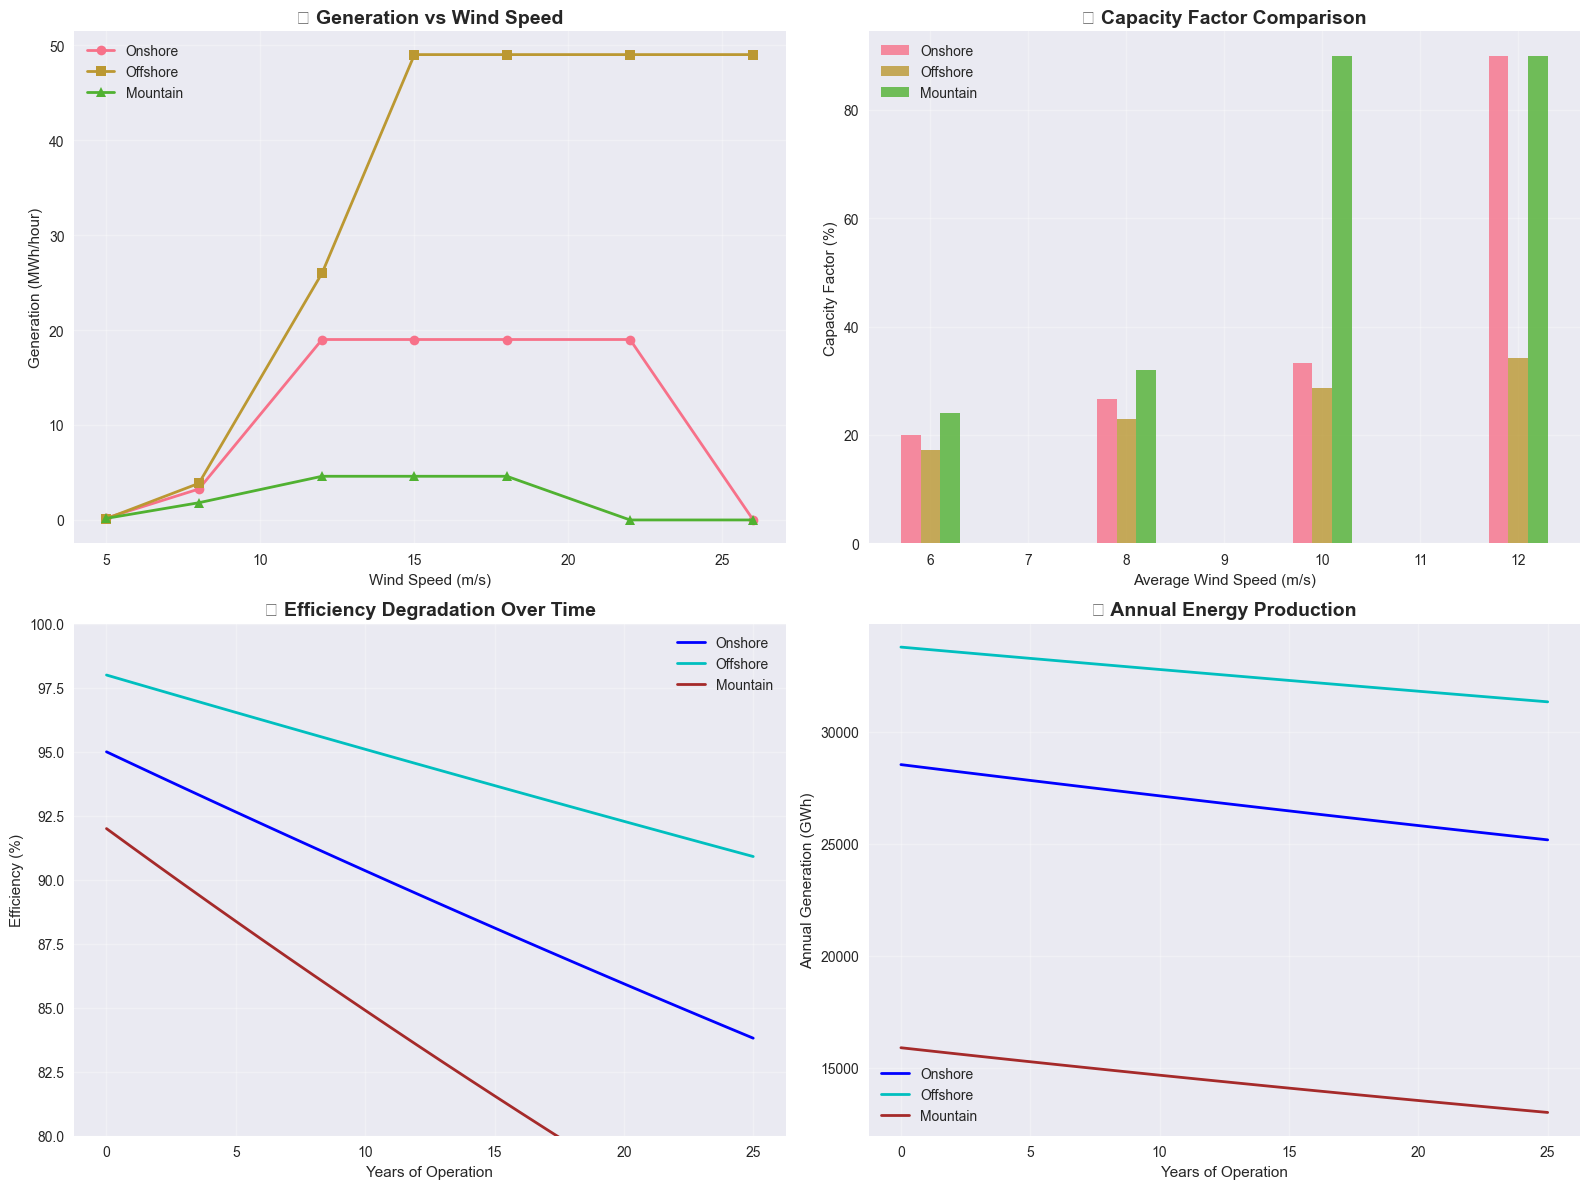


🌟 25-Year Performance Summary (8 m/s average wind):
Onshore:  Initial: 28.5 GWh/year, Final: 25.2 GWh/year (-11.8%)
Offshore: Initial: 33.8 GWh/year, Final: 31.3 GWh/year (-7.2%)
Mountain: Initial: 15.9 GWh/year, Final: 13.0 GWh/year (-18.2%)

💰 Total 25-Year Generation:
Onshore:  697.4 GWh
Offshore: 846.3 GWh
Mountain: 374.4 GWh


In [4]:
# 1. Generation Analysis - Different Wind Speeds
wind_speeds_test = [5, 8, 12, 15, 18, 22, 26]  # Various wind speeds (m/s)
duration = 1.0  # 1 hour generation

print("⚡ Generation Analysis (1-hour duration):")
print("Wind Speed | Onshore | Offshore | Mountain")
print("-----------|---------|----------|----------")

generation_data = []
for speed in wind_speeds_test:
    onshore_gen = onshore_wind.calculate_generation(speed, duration)
    offshore_gen = offshore_wind.calculate_generation(speed, duration)
    mountain_gen = mountain_wind.calculate_generation(speed, duration)
    
    print(f"{speed:2d} m/s     | {onshore_gen:6.2f}  | {offshore_gen:7.2f}  | {mountain_gen:7.2f}")
    
    generation_data.append({
        'wind_speed': speed,
        'onshore': onshore_gen,
        'offshore': offshore_gen,
        'mountain': mountain_gen
    })

# 2. Capacity Factor Analysis
print(f"\n📊 Capacity Factor Analysis:")
average_wind_speeds = [6, 8, 10, 12]  # Different site wind conditions

for avg_speed in average_wind_speeds:
    onshore_cf = onshore_wind.calculate_capacity_factor(avg_speed)
    offshore_cf = offshore_wind.calculate_capacity_factor(avg_speed)
    mountain_cf = mountain_wind.calculate_capacity_factor(avg_speed)
    
    print(f"Average {avg_speed} m/s: Onshore {onshore_cf:.1%}, Offshore {offshore_cf:.1%}, Mountain {mountain_cf:.1%}")

# 3. Degradation Analysis Over Time
years = np.linspace(0, 25, 26)  # 25-year project life
onshore_degradation = [onshore_wind.assess_degradation(year) for year in years]
offshore_degradation = [offshore_wind.assess_degradation(year) for year in years]
mountain_degradation = [mountain_wind.assess_degradation(year) for year in years]

# 4. Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Generation vs Wind Speed
gen_df = pd.DataFrame(generation_data)
ax1.plot(gen_df['wind_speed'], gen_df['onshore'], 'o-', linewidth=2, label='Onshore')
ax1.plot(gen_df['wind_speed'], gen_df['offshore'], 's-', linewidth=2, label='Offshore')
ax1.plot(gen_df['wind_speed'], gen_df['mountain'], '^-', linewidth=2, label='Mountain')
ax1.set_title('⚡ Generation vs Wind Speed', fontsize=14, fontweight='bold')
ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Generation (MWh/hour)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Capacity Factor Comparison
cf_speeds = [6, 8, 10, 12]
cf_onshore = [onshore_wind.calculate_capacity_factor(s) for s in cf_speeds]
cf_offshore = [offshore_wind.calculate_capacity_factor(s) for s in cf_speeds]
cf_mountain = [mountain_wind.calculate_capacity_factor(s) for s in cf_speeds]

ax2.bar([s-0.2 for s in cf_speeds], [cf*100 for cf in cf_onshore], 0.2, label='Onshore', alpha=0.8)
ax2.bar(cf_speeds, [cf*100 for cf in cf_offshore], 0.2, label='Offshore', alpha=0.8)
ax2.bar([s+0.2 for s in cf_speeds], [cf*100 for cf in cf_mountain], 0.2, label='Mountain', alpha=0.8)
ax2.set_title('📊 Capacity Factor Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Wind Speed (m/s)')
ax2.set_ylabel('Capacity Factor (%)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Degradation Over Time
ax3.plot(years, [eff*100 for eff in onshore_degradation], 'b-', linewidth=2, label='Onshore')
ax3.plot(years, [eff*100 for eff in offshore_degradation], 'c-', linewidth=2, label='Offshore')
ax3.plot(years, [eff*100 for eff in mountain_degradation], 'brown', linewidth=2, label='Mountain')
ax3.set_title('📉 Efficiency Degradation Over Time', fontsize=14, fontweight='bold')
ax3.set_xlabel('Years of Operation')
ax3.set_ylabel('Efficiency (%)')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_ylim(80, 100)

# Annual Energy Production (assuming 8 m/s average wind)
annual_hours = 8760  # hours per year
avg_wind_8ms = 8.0

annual_onshore = []
annual_offshore = []
annual_mountain = []

for year in years:
    # Account for degradation
    onshore_eff = onshore_wind.assess_degradation(year)
    offshore_eff = offshore_wind.assess_degradation(year)
    mountain_eff = mountain_wind.assess_degradation(year)
    
    # Calculate annual generation
    onshore_annual = onshore_wind.calculate_generation(avg_wind_8ms, annual_hours) * (onshore_eff / onshore_wind.initial_efficiency)
    offshore_annual = offshore_wind.calculate_generation(avg_wind_8ms, annual_hours) * (offshore_eff / offshore_wind.initial_efficiency)
    mountain_annual = mountain_wind.calculate_generation(avg_wind_8ms, annual_hours) * (mountain_eff / mountain_wind.initial_efficiency)
    
    annual_onshore.append(onshore_annual)
    annual_offshore.append(offshore_annual)
    annual_mountain.append(mountain_annual)

ax4.plot(years, annual_onshore, 'b-', linewidth=2, label='Onshore')
ax4.plot(years, annual_offshore, 'c-', linewidth=2, label='Offshore')
ax4.plot(years, annual_mountain, 'brown', linewidth=2, label='Mountain')
ax4.set_title('📈 Annual Energy Production', fontsize=14, fontweight='bold')
ax4.set_xlabel('Years of Operation')
ax4.set_ylabel('Annual Generation (GWh)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n🌟 25-Year Performance Summary (8 m/s average wind):")
print(f"Onshore:  Initial: {annual_onshore[0]/1000:.1f} GWh/year, Final: {annual_onshore[-1]/1000:.1f} GWh/year ({(annual_onshore[-1]/annual_onshore[0]-1)*100:+.1f}%)")
print(f"Offshore: Initial: {annual_offshore[0]/1000:.1f} GWh/year, Final: {annual_offshore[-1]/1000:.1f} GWh/year ({(annual_offshore[-1]/annual_offshore[0]-1)*100:+.1f}%)")
print(f"Mountain: Initial: {annual_mountain[0]/1000:.1f} GWh/year, Final: {annual_mountain[-1]/1000:.1f} GWh/year ({(annual_mountain[-1]/annual_mountain[0]-1)*100:+.1f}%)")

total_onshore = sum(annual_onshore) / 1000
total_offshore = sum(annual_offshore) / 1000  
total_mountain = sum(annual_mountain) / 1000

print(f"\n💰 Total 25-Year Generation:")
print(f"Onshore:  {total_onshore:.1f} GWh")
print(f"Offshore: {total_offshore:.1f} GWh") 
print(f"Mountain: {total_mountain:.1f} GWh")